<a href="https://colab.research.google.com/github/Karsang-Chhombay-sherpa/DeepLearning/blob/main/MNIST_Digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing dependencies
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

# Loading the MNIST data from keras.datasets

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
type(X_train)

numpy.ndarray

In [4]:
print("X_TRAIN:", X_train.shape,"\nX_test: ",X_test.shape,"\ny_train : ",y_train.shape,"\ny_test : ",y_test.shape)

X_TRAIN: (60000, 28, 28) 
X_test:  (10000, 28, 28) 
y_train :  (60000,) 
y_test :  (10000,)


training data=60,000 images
test data = 10000 images

image dimension = 28*28
grayscale image = 1 color channel

In [5]:
 #printing the 10th image
 print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [6]:
X_train[10].shape

(28, 28)

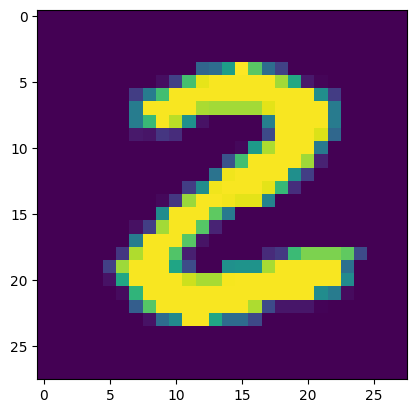

np.uint8(2)

In [7]:
#display the image
plt.imshow(X_train[25])
plt.show()

#print the coresponding label
y_train[25]

In [8]:
print(y_train.shape,y_test.shape)

(60000,) (10000,)


In [9]:
print("Y_train unique value : ",np.unique(y_train))
print("Y_test unique value  : ",np.unique(y_test))

Y_train unique value :  [0 1 2 3 4 5 6 7 8 9]
Y_test unique value  :  [0 1 2 3 4 5 6 7 8 9]


we can use this label as such or we can apply one hot encoding

all the images have same dimension in this datasets as it is preprocessed dataset. if not we have to resize it to common dimension as deep learning aspect same dimension images

In [10]:
#scale the values (Normalization)
X_train=X_train/255
X_test=X_test/255

we convert the information of the images into smaller numbers without changing the imformation ,our model's performance becomes better


In [11]:
X_train[10]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

# BUILDING THE NEURAL NETWORKS

In [12]:
from tensorflow.keras.layers import Flatten

In [13]:
 #setting up the layers of the neural networks
 model=keras.Sequential([
     keras.Input(shape=(28,28)),
     Flatten(),
     keras.layers.Dense(50,activation='relu'),
     keras.layers.Dense(50,activation='relu'),
     keras.layers.Dense(10,activation='sigmoid')
 ])

In [14]:
#compiling the neural networks
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
#training the neural Networks
model.fit(X_train,y_train , epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9122 - loss: 0.3028
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9570 - loss: 0.1438
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9686 - loss: 0.1044
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9752 - loss: 0.0814
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9800 - loss: 0.0659
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9837 - loss: 0.0543
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9863 - loss: 0.0454
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9880 - loss: 0.0390
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9892 - loss: 0.0348
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9904 - loss: 0.0295


Training data accuracy =98.9%

# ACCURACY ON TEST DATA

In [16]:
loss , accuracy=model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9708 - loss: 0.1111


Testing data accuracy is 96.9%

In [17]:
print(X_test.shape)

(10000, 28, 28)


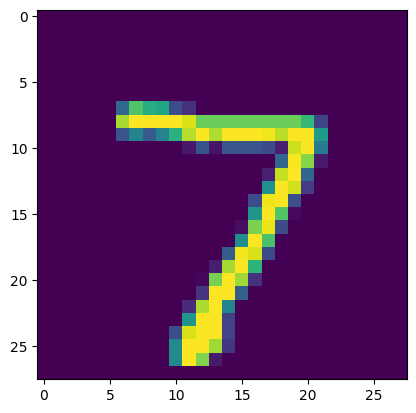

In [18]:
#first data point in X_test
plt.imshow(X_test[0])
plt.show()

In [19]:
y_test[0]

np.uint8(7)

In [20]:
y_pred=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [21]:
y_pred.shape

(10000, 10)

In [22]:
y_pred[0]

array([9.0932278e-03, 3.4345383e-05, 1.8395271e-02, 9.5749873e-01,
       3.8966818e-03, 1.4983782e-03, 2.1355901e-12, 9.9999988e-01,
       9.5913891e-04, 5.1749963e-01], dtype=float32)

model.predict() gives the prediction probability of each class(0-9) for the particular data point

In [23]:
#converting the prediction probabilities to class label
label_for_first_image=np.argmax(y_pred[0])
label_for_first_image

np.int64(7)

In [24]:
#converting the prediction probabilities to class label for all test data points
y_pred_labels=[np.argmax(i) for i in y_pred]
y_pred_labels

[np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(5),
 np.int64(9),
 np.int64(0),
 np.int64(6),
 np.int64(9),
 np.int64(0),
 np.int64(1),
 np.int64(5),
 np.int64(9),
 np.int64(7),
 np.int64(3),
 np.int64(4),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.int64(0),
 np.int64(7),
 np.int64(4),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(4),
 np.int64(7),
 np.int64(2),
 np.int64(7),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(7),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(4),
 np.int64(6),
 np.int64(3),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(9),
 np.int64(5),
 np.int64(7),
 np.int64(8),
 np.int64(8),
 np.int64(3),
 np.int64(7),
 np.int64(4),
 np.int64(6),
 np.int64(4),
 np.int64(3),
 np.int64(0),
 np.int64(7),
 np.in

y_test ----> True Labels


y_pred_labels ------> Predicted Labels

# CONFUSION MATRIX

In [25]:
from tensorflow.math import confusion_matrix
conf_mat=confusion_matrix(y_test,y_pred_labels)

In [26]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 956,    0,    0,    2,    2,    0,    3,    1,    4,   12],
       [   0, 1114,    2,    5,    0,    1,    4,    1,    8,    0],
       [   6,    1,  983,   18,    4,    1,    2,    6,   11,    0],
       [   0,    0,    0,  993,    0,    2,    0,    3,    5,    7],
       [   0,    0,    3,    0,  955,    0,    7,    1,    2,   14],
       [   0,    0,    0,   12,    3,  861,    7,    1,    5,    3],
       [   2,    2,    0,    0,    4,    9,  938,    0,    3,    0],
       [   0,    3,   10,    7,    2,    0,    0,  978,    7,   21],
       [   2,    0,    2,   15,    3,    4,    4,    2,  939,    3],
       [   1,    2,    0,    4,    3,    2,    1,    2,    3,  991]],
      dtype=int32)>

Text(0.5, 47.7222222222222, 'Predicted labels')

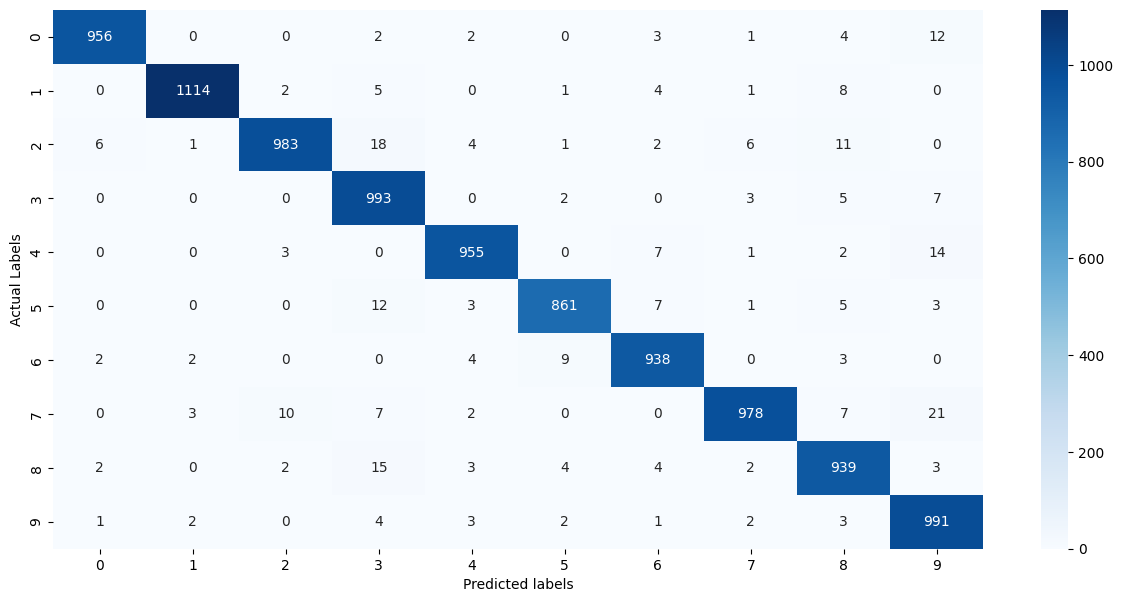

In [27]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat,annot=True,fmt='d',cmap='Blues')
plt.ylabel("Actual Labels")
plt.xlabel("Predicted labels")

# Building Predictive System

In [28]:
input_image_path=('/content/drive/MyDrive/ai/images/MNIST_digit.png')

In [30]:
input_image=cv2.imread(input_image_path)

In [32]:
type(input_image)

numpy.ndarray

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
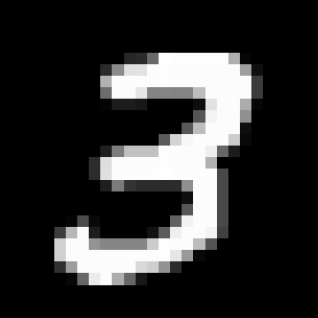

In [33]:
input_image

In [34]:
input_image.shape

(318, 318, 3)

In [37]:
grayscale=cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)

In [38]:
input_image_resize=cv2.resize(grayscale,(28,28))

In [39]:
cv2_imshow(input_image_resize)

In [40]:
input_image_resize.shape

(28, 28)

In [41]:
input_image_resize=input_image_resize/255

In [43]:
type(input_image_resize)

numpy.ndarray

In [45]:
image_reshape=np.reshape(input_image_resize,[1,28,28]) #i am ging to predict for only 1 image with 28*28 dimension

In [44]:
type(image_reshape)

numpy.ndarray

In [46]:
input_prediction=model.predict(image_reshape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [47]:
input_prediction

array([[1.4786354e-10, 4.4107503e-05, 1.1360034e-06, 1.0000000e+00,
        3.7006875e-13, 1.3220384e-03, 1.1603465e-17, 5.7556015e-05,
        1.1027349e-03, 3.9839953e-01]], dtype=float32)

In [48]:
input_pred_label=np.argmax(input_prediction)

In [49]:
input_pred_label

np.int64(3)

# PREDICTIVE SYSTEM

In [56]:
input_image_path=input("enter the path of the image to be predicted")
input_image=cv2.imread(input_image_path)
type(input_image)
grayscale=cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)
image_resize=cv2.resize(grayscale,(28,28))
image_reshape=np.reshape(image_resize,[1,28,28])
model_prediction=model.predict(image_reshape)
model_pred_label=np.argmax(model_prediction)
print("Handwritten image recognize as : ",model_pred_label)

enter the path of the image to be predicted/content/drive/MyDrive/ai/images/MNIST_digit.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Handwritten image recognize as :  3
